# Pipeline RUL (Remaining Useful Life) Prediction


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported")

Libraries imported


### Phase 1: Data Preparation

### Step 1: Import Libraries and Load Dataset

In [2]:
# Load the pipeline dataset (UPDATED: Using r_density.csv)
df = pd.read_csv("r_density.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"Number of pipes: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

df.head()


Dataset shape: (8193, 13)
Number of pipes: 8193
Number of features: 13


,VIBRATION FREQUENCY,FREQUENCY,TIME,PIPE-LENGTH,VELOCITY,PIPE DENSITY,RADIUS,AREA,MASS,ACCELERA,VOLUME,FORCE,PRESSURE
0,0.000000,15.438463,0.064773,21,324.207723,0.086748,2.25,15.906375,28.976843,5005.268936,334.033875,28.976843,1.821713
1,0.000122,27.371195,0.036535,42,1149.590190,0.086748,2.25,15.906375,57.953686,31465.657260,668.067750,57.953686,3.643425
2,0.000244,28.371534,0.035247,63,1787.406642,0.086748,2.25,15.906375,86.930528,50711.468320,1002.101625,86.930528,5.465138
3,0.000366,35.004757,0.028568,84,2940.399588,0.086748,2.25,15.906375,115.907371,102927.973100,1336.135500,115.907371,7.286850
4,0.000488,29.962458,0.033375,105,3146.058090,0.086748,2.25,15.906375,144.884214,94263.633390,1670.169375,144.884214,9.108563


In [3]:
# Check columns with constant values
print(df.nunique())


VIBRATION FREQUENCY    8192
FREQUENCY              4199
TIME                   4192
PIPE-LENGTH            8193
VELOCITY               8193
PIPE DENSITY              1
RADIUS                    1
AREA                      1
MASS                   8193
ACCELERA               8191
VOLUME                 8193
FORCE                  8193
PRESSURE               8193
dtype: int64


### Step 2: Data Cleaning and Feature Selection

In [4]:
# Keep only key features needed for degradation modeling

df_clean = df[['VIBRATION FREQUENCY', 'PRESSURE', 'VELOCITY', 'PIPE-LENGTH']].copy()

print(f"Selected {df_clean.shape[1]} key features")
print(f"Reduced Dataset from {df.shape[1]} to {df_clean.shape[1]} columns")
print(df_clean.columns.tolist())
print(f"\nCleaned dataset shape: {df_clean.shape}")
df_clean.head()

Selected 4 key features
Reduced Dataset from 13 to 4 columns
['VIBRATION FREQUENCY', 'PRESSURE', 'VELOCITY', 'PIPE-LENGTH']

Cleaned dataset shape: (8193, 4)


,VIBRATION FREQUENCY,PRESSURE,VELOCITY,PIPE-LENGTH
0,0.000000,1.821713,324.207723,21
1,0.000122,3.643425,1149.590190,42
2,0.000244,5.465138,1787.406642,63
3,0.000366,7.286850,2940.399588,84
4,0.000488,9.108563,3146.058090,105


In [5]:
# Randomly Sample 2,000 pipes for time-series generation Using stratified 
np.random.seed(42)

SAMPLE_SIZE = 2000

# Randomly sample 2000 pipes
df_sampled = df_clean.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# Add a unique PIPE_ID to each pipe
df_sampled['PIPE_ID'] = range(1, SAMPLE_SIZE + 1)

print(f"Dataset shape: {df_sampled.shape}")
print(df_sampled.columns.tolist())
df_sampled.head()

Dataset shape: (2000, 5)
['VIBRATION FREQUENCY', 'PRESSURE', 'VELOCITY', 'PIPE-LENGTH', 'PIPE_ID']


,VIBRATION FREQUENCY,PRESSURE,VELOCITY,PIPE-LENGTH,PIPE_ID
0,0.692261,10332.753520,9.151765e+06,119112,1
1,0.704468,10514.924770,8.715751e+06,121212,2
2,0.257690,3847.456881,3.205169e+06,44352,3
3,0.812988,12134.427220,1.045331e+07,139881,4
4,0.638184,9525.734862,8.347641e+06,109809,5


In [6]:
# Statistics of sampled pipes

print("BASELINE STATISTICS (healthy pipe states)")
print("\nSDescriptive Statistics of sampled pipes:")
print(df_sampled.describe())


BASELINE STATISTICS (healthy pipe states)

SDescriptive Statistics of sampled pipes:
       VIBRATION FREQUENCY      PRESSURE      VELOCITY    PIPE-LENGTH  \
count          2000.000000   2000.000000  2.000000e+03    2000.000000   
mean              0.494405   7380.062629  6.110524e+06   85074.517500   
std               0.292288   4361.974979  3.430585e+06   50283.166324   
min               0.000000      1.821713  3.242077e+02      21.000000   
25%               0.234222   3497.232645  3.022635e+06   40314.750000   
50%               0.493103   7360.629511  6.496506e+06   84850.500000   
75%               0.745636  11129.297328  9.235866e+06  128294.250000   
max               0.999146  14914.360550  1.415545e+07  171927.000000   

           PIPE_ID  
count  2000.000000  
mean   1000.500000  
std     577.494589  
min       1.000000  
25%     500.750000  
50%    1000.500000  
75%    1500.250000  
max    2000.000000  


In [7]:
# Degradation model parameters
MAX_LIFETIME = 3650  # days (10 years)
MEASUREMENT_FREQ = 7  # measure every 7 days (weekly)
TIME_POINTS = np.arange(0, MAX_LIFETIME + MEASUREMENT_FREQ, MEASUREMENT_FREQ)
N_TIME_POINTS = len(TIME_POINTS)

# Environmental stress factor range (±15% variation)
ENV_STRESS_MIN = 0.85
ENV_STRESS_MAX = 1.15

# Degradation rates for each feature (by end of life)
PRESSURE_DROP = 0.30      # 30% pressure decrease
VIBRATION_INCREASE = 7.0  # 8x vibration increase
VELOCITY_DROP = 0.15      # 15% velocity decrease

# Non-linear degradation exponent
DEGRADATION_EXPONENT = 2.5

# Random shock parameters
SHOCK_PROBABILITY = 0.05  # 5% chance per month
SHOCK_INTERVAL = 30       # check every 30 days

# Sensor noise
SENSOR_NOISE = 0.03       # ±3% measurement error


print("DEGRADATION MODEL PARAMETERS::")

print(f"Maximum lifetime: {MAX_LIFETIME} days ({MAX_LIFETIME/365:.1f} years)")
print(f"Measurement frequency: Every {MEASUREMENT_FREQ} days (weekly)")
print(f"Time points per pipe: {N_TIME_POINTS}")
print(f"Environmental stress range: {ENV_STRESS_MIN} - {ENV_STRESS_MAX}")
print(f"Pressure degradation: -{PRESSURE_DROP*100}%")
print(f"Vibration degradation: +{VIBRATION_INCREASE*100}%")
print(f"Velocity degradation: -{VELOCITY_DROP*100}%")
print(f"Sensor noise: ±{SENSOR_NOISE*100}%")


DEGRADATION MODEL PARAMETERS::
Maximum lifetime: 3650 days (10.0 years)
Measurement frequency: Every 7 days (weekly)
Time points per pipe: 523
Environmental stress range: 0.85 - 1.15
Pressure degradation: -30.0%
Vibration degradation: +700.0%
Velocity degradation: -15.0%
Sensor noise: ±3.0%


## Step 5: Create Simple Degradation Function

This is a function takes 1 pipe and creates a complete 10-year timeline (523 weekly measurements) for the pipe.
  
   
Generate a 10-year degradation timeline for 1 pipe Using simple degradation rules based on engineering principles:
- Pressure drops 30% (ASME B31.8)
- Vibration increases 8x (ISO 10816)
- Velocity drops 15% (Darcy-Weisbach)
- Degradation accelerates over time (Paris' Law concept)
    
Returns: List of 523 measurements (one per week for 10 years)


In [8]:
def generate_degradation_timeline(pipe_id, initial_vibration, initial_pressure, initial_velocity, pipe_length):
  
    
    # Random failure time (between 50% and 100% of max lifetime)
    failure_day = np.random.uniform(MAX_LIFETIME * 0.5, MAX_LIFETIME)
    
    # Random environment factor (±15% variation in degradation speed)
    env_stress = np.random.uniform(ENV_STRESS_MIN, ENV_STRESS_MAX)
    
    # Track cumulative shock damage
    shock_damage = 0.0
    
    # Store all time points for this pipe
    timeline = []
    
    # Loop through each week for 10 years
    for day in TIME_POINTS:
        
        # Calculate how far along to failure (0 = start, 1 = failed)
        progress = min(day / failure_day, 1.0)
        
        # Non-linear degradation (accelerates: progress^2.5)
        degradation = (progress ** DEGRADATION_EXPONENT) * env_stress
        
        # Add random shocks (sudden damage events)
        if day > 0 and day % SHOCK_INTERVAL == 0:  # Check monthly
            if np.random.random() < SHOCK_PROBABILITY:
                shock_damage += np.random.uniform(0.05, 0.15)
        
        # PRESSURE decreases (structural weakening)
        pressure = initial_pressure * (1 - PRESSURE_DROP * degradation)
        pressure = pressure * (1 - shock_damage * 0.5)  # Shocks accelerate pressure loss
        pressure = max(pressure, 0.1 * initial_pressure)  # Can't go below 10%
        
        # VIBRATION increases (cracks/instability)
        vibration = initial_vibration * (1 + VIBRATION_INCREASE * degradation)
        vibration = vibration * (1 + shock_damage * 2.0)  # Shocks amplify vibration
        
        # VELOCITY decreases (flow restriction)
        velocity = initial_velocity * (1 - VELOCITY_DROP * degradation)
        velocity = velocity * (1 - shock_damage * 0.3)
        velocity = max(velocity, 0.1 * initial_velocity)  # Can't go below 10%
        
        # Add sensor noise (±3% measurement error)
        vibration_measured = vibration * np.random.uniform(1 - SENSOR_NOISE, 1 + SENSOR_NOISE)
        pressure_measured = pressure * np.random.uniform(1 - SENSOR_NOISE, 1 + SENSOR_NOISE)
        velocity_measured = velocity * np.random.uniform(1 - SENSOR_NOISE, 1 + SENSOR_NOISE)
        
        # Calculate days until failure (TARGET for ML model)
        days_until_failure = max(0, failure_day - day)
        
        # Save this time point
        timeline.append({
            'PIPE_ID': pipe_id,
            'DAY': day,
            'VIBRATION FREQUENCY': vibration_measured,
            'PRESSURE': pressure_measured,
            'VELOCITY': velocity_measured,
            'PIPE-LENGTH': pipe_length,  # Physical property (constant per pipe, varies between pipes)
            'RUL': days_until_failure  # Remaining Useful Life (TARGET)
        })
    
    return timeline

print("function created")


function created


## Step 6: Generate Time-Series for All 2,000 Pipes



In [9]:
import time


start_time = time.time()

# Store all timelines here
all_timelines = []

# Loop through each pipe
for idx, row in df_sampled.iterrows():
    
    # Show progress every 200 pipes
    if (idx + 1) % 200 == 0:
        elapsed = time.time() - start_time
        rate = (idx + 1) / elapsed
        remaining = (len(df_sampled) - (idx + 1)) / rate
        print(f"  Progress: {idx + 1}/{len(df_sampled)} pipes | "
              f"Elapsed: {elapsed:.1f}s | ETA: {remaining:.1f}s")
    
    # Generate timeline for this pipe
    pipe_timeline = generate_degradation_timeline(
        pipe_id=row['PIPE_ID'],
        initial_vibration=row['VIBRATION FREQUENCY'],
        initial_pressure=row['PRESSURE'],
        initial_velocity=row['VELOCITY'],
        pipe_length=row['PIPE-LENGTH']
    )
    
    # Add to collection
    all_timelines.extend(pipe_timeline)

# Convert to DataFrame
df_timeseries = pd.DataFrame(all_timelines)

end_time = time.time()


print(f"COMPLETE")
print(f"\nResults:")
print(f"  • Total rows generated: {len(df_timeseries):,}")
print(f"  • Unique pipes: {df_timeseries['PIPE_ID'].nunique()}")

print(f"  • Dataset shape: {df_timeseries.shape}")

  Progress: 200/2000 pipes | Elapsed: 1.9s | ETA: 17.0s
  Progress: 400/2000 pipes | Elapsed: 3.8s | ETA: 15.0s
  Progress: 600/2000 pipes | Elapsed: 6.6s | ETA: 15.5s
  Progress: 800/2000 pipes | Elapsed: 9.2s | ETA: 13.8s
  Progress: 1000/2000 pipes | Elapsed: 11.2s | ETA: 11.2s
  Progress: 1200/2000 pipes | Elapsed: 13.3s | ETA: 8.8s
  Progress: 1400/2000 pipes | Elapsed: 15.3s | ETA: 6.6s
  Progress: 1600/2000 pipes | Elapsed: 17.2s | ETA: 4.3s
  Progress: 1800/2000 pipes | Elapsed: 19.1s | ETA: 2.1s
  Progress: 2000/2000 pipes | Elapsed: 21.1s | ETA: 0.0s
COMPLETE

Results:
  • Total rows generated: 1,046,000
  • Unique pipes: 2000
  • Dataset shape: (1046000, 7)


In [10]:
# Preview the time-series data

print(f"Shape: {df_timeseries.shape}")
print(f"\nFirst 10 rows (Pipe #1 first week):")
df_timeseries.head(10)

Shape: (1046000, 7)

First 10 rows (Pipe #1 first week):


,PIPE_ID,DAY,VIBRATION FREQUENCY,PRESSURE,VELOCITY,PIPE-LENGTH,RUL
0,1.0,0,0.701897,10393.918348,8.962883e+06,119112.0,2508.535717
1,1.0,7,0.677974,10058.779324,9.352834e+06,119112.0,2501.535717
2,1.0,14,0.696473,10461.742989,8.888512e+06,119112.0,2494.535717
3,1.0,21,0.711815,10538.833378,8.993799e+06,119112.0,2487.535717
4,1.0,28,0.679116,10136.429891,9.044253e+06,119112.0,2480.535717
5,1.0,35,0.693416,10290.481213,9.037092e+06,119112.0,2473.535717
6,1.0,42,0.697107,10109.127376,9.037575e+06,119112.0,2466.535717
7,1.0,49,0.687001,10305.331280,9.308272e+06,119112.0,2459.535717
8,1.0,56,0.680189,10341.316133,9.202394e+06,119112.0,2452.535717
9,1.0,63,0.673957,10399.073582,8.970695e+06,119112.0,2445.535717


## Step 8: Visualize Degradation Patterns

plot how sensor readings change over time for 5 random pipes to verify realistic degradation.

Visualizing degradation for 5 sample pipes: [1861.  354. 1334.  906. 1290.]


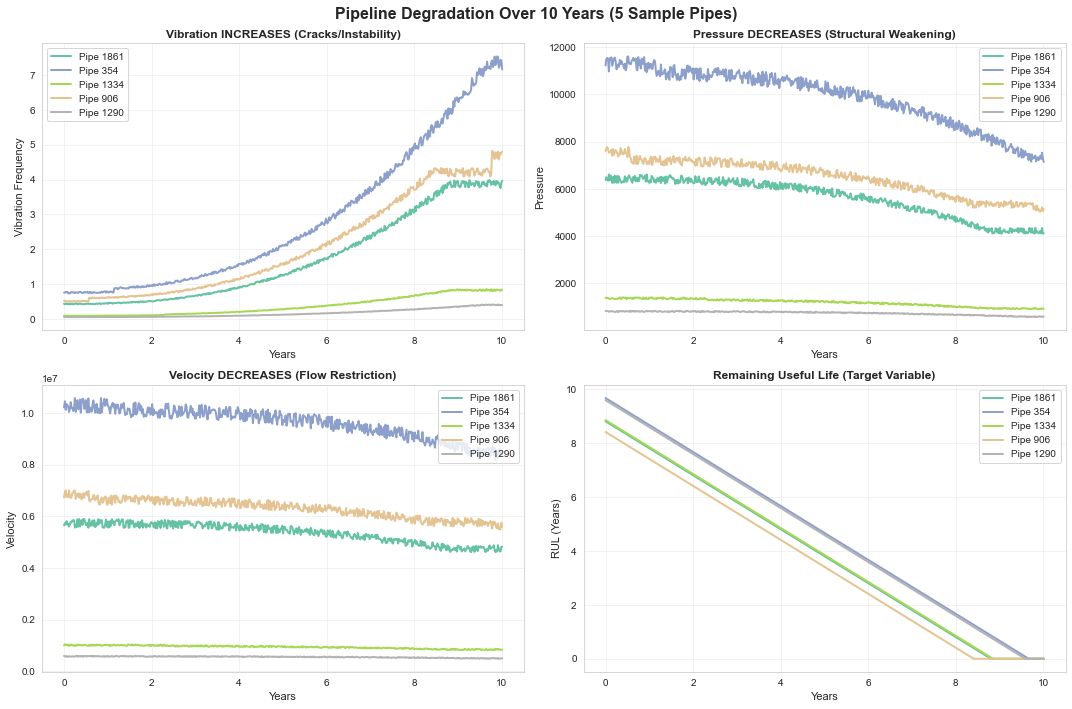

In [11]:
# Select 5 random pipes to visualize
np.random.seed(42)
sample_pipe_ids = np.random.choice(df_timeseries['PIPE_ID'].unique(), size=5, replace=False)

print(f"Visualizing degradation for 5 sample pipes: {sample_pipe_ids}")

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Pipeline Degradation Over 10 Years (5 Sample Pipes)', fontsize=16, fontweight='bold')

# Color palette
colors = plt.cm.Set2(np.linspace(0, 1, 5))

# Plot 1: Vibration Frequency (INCREASES)
ax = axes[0, 0]
for i, pipe_id in enumerate(sample_pipe_ids):
    pipe_data = df_timeseries[df_timeseries['PIPE_ID'] == pipe_id]
    ax.plot(pipe_data['DAY'] / 365, pipe_data['VIBRATION FREQUENCY'], 
            label=f'Pipe {int(pipe_id)}', color=colors[i], linewidth=2)
ax.set_xlabel('Years', fontsize=11)
ax.set_ylabel('Vibration Frequency', fontsize=11)
ax.set_title('Vibration INCREASES (Cracks/Instability)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Pressure (DECREASES)
ax = axes[0, 1]
for i, pipe_id in enumerate(sample_pipe_ids):
    pipe_data = df_timeseries[df_timeseries['PIPE_ID'] == pipe_id]
    ax.plot(pipe_data['DAY'] / 365, pipe_data['PRESSURE'], 
            label=f'Pipe {int(pipe_id)}', color=colors[i], linewidth=2)
ax.set_xlabel('Years', fontsize=11)
ax.set_ylabel('Pressure', fontsize=11)
ax.set_title('Pressure DECREASES (Structural Weakening)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Velocity (DECREASES)
ax = axes[1, 0]
for i, pipe_id in enumerate(sample_pipe_ids):
    pipe_data = df_timeseries[df_timeseries['PIPE_ID'] == pipe_id]
    ax.plot(pipe_data['DAY'] / 365, pipe_data['VELOCITY'], 
            label=f'Pipe {int(pipe_id)}', color=colors[i], linewidth=2)
ax.set_xlabel('Years', fontsize=11)
ax.set_ylabel('Velocity', fontsize=11)
ax.set_title('Velocity DECREASES (Flow Restriction)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Remaining Useful Life (DECREASES)
ax = axes[1, 1]
for i, pipe_id in enumerate(sample_pipe_ids):
    pipe_data = df_timeseries[df_timeseries['PIPE_ID'] == pipe_id]
    ax.plot(pipe_data['DAY'] / 365, pipe_data['RUL'] / 365, 
            label=f'Pipe {int(pipe_id)}', color=colors[i], linewidth=2)
ax.set_xlabel('Years', fontsize=11)
ax.set_ylabel('RUL (Years)', fontsize=11)
ax.set_title('Remaining Useful Life (Target Variable)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 8b: Observations from degradation patterns

- Vibration accelerates upward I.E exponential
- Pressure drops
- Velocity decreases gradually
- Each pipe fails at different times (5-10 years)
- Degradation is non-linear I.E matches paris law


## Phase 2: Machine Learning Model Training

## Step 9: Prepare Data for ML Training

Split the data correctly to avoid data leakage while keeping all timepoints from one pipe together i.e ensire no pipe appears in both training and testing

In [12]:
# Prepare features and target

X = df_timeseries[['DAY', 'VIBRATION FREQUENCY', 'PRESSURE', 'VELOCITY', 'PIPE-LENGTH']].copy()
y = df_timeseries['RUL'].copy()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (1046000, 5)
Target (y) shape: (1046000,)


In [13]:

from sklearn.model_selection import train_test_split

# Get unique pipe IDs
unique_pipes = df_timeseries['PIPE_ID'].unique()
print(f"Total unique pipes: {len(unique_pipes)}")

# Split pipes 70/30
train_pipes, test_pipes = train_test_split(unique_pipes, test_size=0.3, random_state=42)

print(f"Training pipes: {len(train_pipes)} ({len(train_pipes)/len(unique_pipes)*100:.1f}%)")
print(f"Testing pipes: {len(test_pipes)} ({len(test_pipes)/len(unique_pipes)*100:.1f}%)")

# Create train/test datasets
train_mask = df_timeseries['PIPE_ID'].isin(train_pipes)
test_mask = df_timeseries['PIPE_ID'].isin(test_pipes)

X_train = X[train_mask].copy()
X_test = X[test_mask].copy()
y_train = y[train_mask].copy()
y_test = y[test_mask].copy()


print(f"\nTRAIN/TEST SPLIT RESULTS:")

print(f"\nTraining set: {X_train.shape[0]:,} rows ({len(train_pipes)} pipes)")
print(f"Testing set:  {X_test.shape[0]:,} rows ({len(test_pipes)} pipes)")

Total unique pipes: 2000
Training pipes: 1400 (70.0%)
Testing pipes: 600 (30.0%)

TRAIN/TEST SPLIT RESULTS:

Training set: 732,200 rows (1400 pipes)
Testing set:  313,800 rows (600 pipes)


## Step 10: Train XGBoost Regression Model



In [33]:
# Train XGBoost model
from xgboost import XGBRegressor

# Create and train model
model = XGBRegressor(
    n_estimators=100,        # Number of trees
    max_depth=6,             # Maximum tree depth
    learning_rate=0.1,       # Step size shrinkage
    subsample=0.8,           # Fraction of samples per tree
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

# Train the model
model.fit(X_train, y_train)

print(f" training complete")

 training complete


## Step 11: Evaluate XGBoost Model Performance


how well does the XGBoost model predicts RUL

In [34]:
# Make predictions and evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Predict on both sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# results

print(f"\nMODEL PERFORMANCE METRICS")

print(f"{'Metric':<25} {'Training':<20} {'Testing':<20}")

print(f"{'MAE (days)':<25} {train_mae:<20.2f} {test_mae:<20.2f}")
print(f"{'RMSE (days)':<25} {train_rmse:<20.2f} {test_rmse:<20.2f}")
print(f"{'R² Score':<25} {train_r2:<20.4f} {test_r2:<20.4f}")




MODEL PERFORMANCE METRICS
Metric                    Training             Testing             
MAE (days)                171.58               189.97              
RMSE (days)               246.95               275.50              
R² Score                  0.9356               0.9197              


### Step 11b: XGBoost performance interpretation:

In [35]:
print(f"  • MAE = {test_mae:.1f} days: Average prediction error")
print(f"  • RMSE = {test_rmse:.1f} days: Penalizes large errors more")
print(f"  • R² = {test_r2:.4f}: {test_r2*100:.2f}% of variance explained")
print(f"\n Model can predict failure time within ±{test_mae:.0f} days on average!")


  • MAE = 190.0 days: Average prediction error
  • RMSE = 275.5 days: Penalizes large errors more
  • R² = 0.9197: 91.97% of variance explained

 Model can predict failure time within ±190 days on average!


## Step 12: Train Linear Regression Baseline


In [36]:
# Train Linear Regression as baseline
from sklearn.linear_model import LinearRegression

# Create and train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
lr_train_mae = mean_absolute_error(y_train, y_train_pred_lr)
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)

# Calculate MAPE
# Filter out zero/near-zero RUL values i.e pipes already failed to avoid division issues
mask_train = y_train > 1  # calculate MAPE for RUL > 1 day
mask_test = y_test > 1

lr_train_mape = np.mean(np.abs((y_train[mask_train] - y_train_pred_lr[mask_train]) / y_train[mask_train])) * 100
lr_test_mape = np.mean(np.abs((y_test[mask_test] - y_test_pred_lr[mask_test]) / y_test[mask_test])) * 100


print(f"Training complete")


# Display results
print("\nLINEAR REGRESSION MODEL PERFORMANCE")

print(f"{'Metric':<25} {'Training':<20} {'Testing':<20}")

print(f"{'MAE (days)':<25} {lr_train_mae:<20.2f} {lr_test_mae:<20.2f}")
print(f"{'RMSE (days)':<25} {lr_train_rmse:<20.2f} {lr_test_rmse:<20.2f}")
print(f"{'R² Score':<25} {lr_train_r2:<20.4f} {lr_test_r2:<20.4f}")
print(f"{'MAPE (%)':<25} {lr_train_mape:<20.2f} {lr_test_mape:<20.2f}")



Training complete

LINEAR REGRESSION MODEL PERFORMANCE
Metric                    Training             Testing             
MAE (days)                366.30               365.40              
RMSE (days)               446.31               445.32              
R² Score                  0.7897               0.7902              
MAPE (%)                  108.64               106.79              


## Step 12b: Linear Regression Model Performance Observation


In [38]:
print(f"  • R² = {lr_test_r2:.4f} ({lr_test_r2*100:.1f}%) : Linear model performs poorly")
print(f"  • MAE = {lr_test_mae:.1f} days : Perfroms much worse than XGBoost ({test_mae:.1f} days)")
print(f"  • MAPE = {lr_test_mape:.1f}% :  High relative error")

print(f"\nLR Fails because it assumes linear relationships (y = mx + b). But the degradation is NON-LINEAR (progress^2.5")

print(f"Thus it cannot capture exponential acceleration in failure rates")

  • R² = 0.7902 (79.0%) : Linear model performs poorly
  • MAE = 365.4 days : Perfroms much worse than XGBoost (190.0 days)
  • MAPE = 106.8% :  High relative error

LR Fails because it assumes linear relationships (y = mx + b). But the degradation is NON-LINEAR (progress^2.5
Thus it cannot capture exponential acceleration in failure rates


## Step 13: Algorithm Comparison with MAPE

compare Linear Regression vs XGBoost across all metrics including MAPE (Mean Absolute Percentage Error).


ALGORITHM COMPARISON: Linear Regression vs XGBoost
        Algorithm  Test MAE (days)  Test RMSE (days)  Test R²  Test MAPE (%) Model-Complexity Non-linear Capability
Linear Regression       365.403854        445.319094 0.790218     106.794197     Low (Linear)                    No
          XGBoost       189.965717        275.497651 0.919710      33.337446  High(100 trees)                   Yes

XGBoost IMPROVEMENTS OVER LINEAR REGRESSION:
  • MAE improved by: 48.0% (365.4 → 190.0 days)
  • R² improved by: 61.7% of remaining variance (0.7902 → 0.9197)
  • MAPE improved by: 68.8% (106.8% → 33.3%)

CONCLUSION:
XGBoost is necessary for this problem:
   1. Linear Regression R² = 79.0% == fails on non-linear degradation
   2. XGBoost R² = 92.0% == Successfully captures t^2.5 degradation
   3. MAPE reduction of 68.8% == Better relative accuracy

Key Insight:
   Linear models assume y = mx + b (straight line)
   But pipeline degradation = progress^2.5 (exponential curve)
   → Tree-based mod

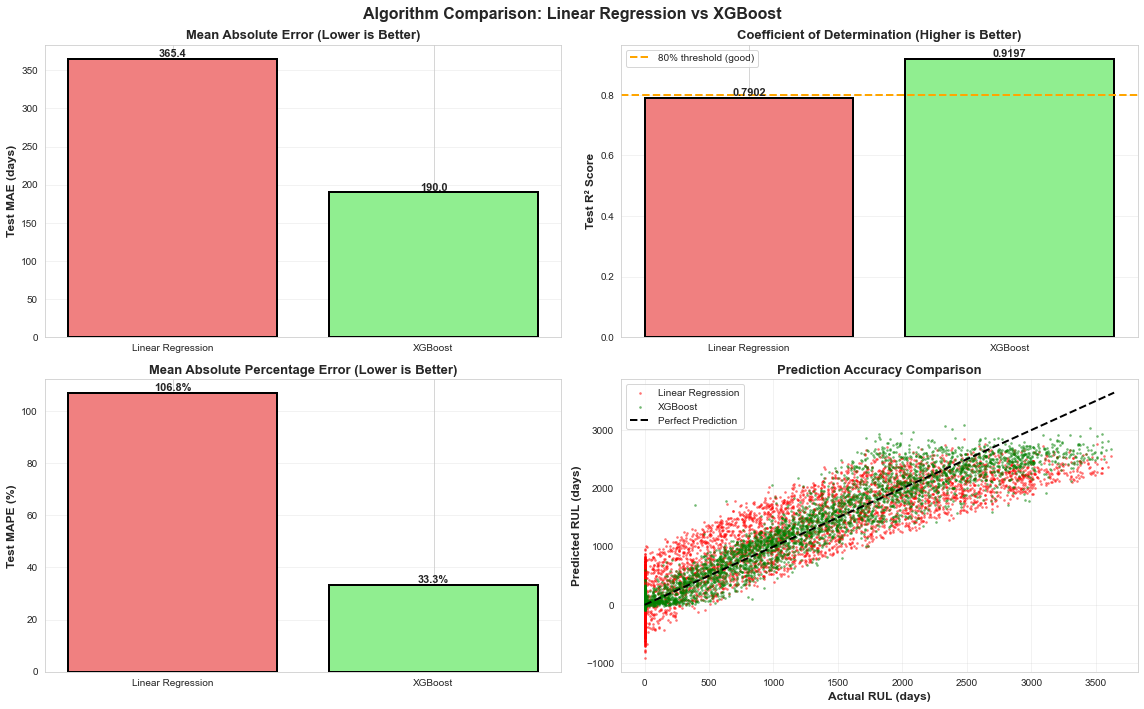


Algorithm comparison complete


In [39]:
# Calculate MAPE for XGBoost (we didn't calculate it earlier)
# Filter out zero/near-zero RUL values (same masks as Linear Regression)
mask_train = y_train > 1  # calculate MAPE for RUL > 1 day
mask_test = y_test > 1

xgb_train_mape = np.mean(np.abs((y_train[mask_train] - y_train_pred[mask_train]) / y_train[mask_train])) * 100
xgb_test_mape = np.mean(np.abs((y_test[mask_test] - y_test_pred[mask_test]) / y_test[mask_test])) * 100

# Create comprehensive comparison table
comparison_results = pd.DataFrame({
    'Algorithm': ['Linear Regression', 'XGBoost'],
    'Test MAE (days)': [lr_test_mae, test_mae],
    'Test RMSE (days)': [lr_test_rmse, test_rmse],
    'Test R²': [lr_test_r2, test_r2],
    'Test MAPE (%)': [lr_test_mape, xgb_test_mape],
    'Model-Complexity': ['Low (Linear)', 'High(100 trees)'],
    'Non-linear Capability': ['No', 'Yes']
})


print(f"\nALGORITHM COMPARISON: Linear Regression vs XGBoost")

print(comparison_results.to_string(index=False))


# Calculate improvements
mae_improvement = ((lr_test_mae - test_mae) / lr_test_mae) * 100
r2_improvement = ((test_r2 - lr_test_r2) / (1 - lr_test_r2)) * 100  # Relative to remaining variance
mape_improvement = ((lr_test_mape - xgb_test_mape) / lr_test_mape) * 100

print(f"\nXGBoost IMPROVEMENTS OVER LINEAR REGRESSION:")
print("="*100)
print(f"  • MAE improved by: {mae_improvement:.1f}% ({lr_test_mae:.1f} → {test_mae:.1f} days)")
print(f"  • R² improved by: {r2_improvement:.1f}% of remaining variance ({lr_test_r2:.4f} → {test_r2:.4f})")
print(f"  • MAPE improved by: {mape_improvement:.1f}% ({lr_test_mape:.1f}% → {xgb_test_mape:.1f}%)")


print(f"\nCONCLUSION:")
print("="*100)
print(f"XGBoost is necessary for this problem:")
print(f"   1. Linear Regression R² = {lr_test_r2:.1%} == fails on non-linear degradation")
print(f"   2. XGBoost R² = {test_r2:.1%} == Successfully captures t^2.5 degradation")
print(f"   3. MAPE reduction of {mape_improvement:.1f}% == Better relative accuracy")

print(f"\nKey Insight:")
print(f"   Linear models assume y = mx + b (straight line)")
print(f"   But pipeline degradation = progress^2.5 (exponential curve)")
print(f"   → Tree-based models (XGBoost) required to learn non-linear patterns!")


# Visualize comparison 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Algorithm Comparison: Linear Regression vs XGBoost', fontsize=16, fontweight='bold')

# Plot 1: MAE Comparison
ax = axes[0, 0]
algorithms = comparison_results['Algorithm']
mae_values = comparison_results['Test MAE (days)']
colors_comp = ['lightcoral', 'lightgreen']
bars = ax.bar(algorithms, mae_values, color=colors_comp, edgecolor='black', linewidth=2)
ax.set_ylabel('Test MAE (days)', fontsize=12, fontweight='bold')
ax.set_title('Mean Absolute Error (Lower is Better)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mae_values.iloc[i]:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: R² Comparison
ax = axes[0, 1]
r2_values = comparison_results['Test R²']
bars = ax.bar(algorithms, r2_values, color=colors_comp, edgecolor='black', linewidth=2)
ax.set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
ax.set_title('Coefficient of Determination (Higher is Better)', fontsize=13, fontweight='bold')
ax.axhline(0.8, color='orange', linestyle='--', linewidth=2, label='80% threshold (good)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{r2_values.iloc[i]:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: MAPE Comparison
ax = axes[1, 0]
mape_values = comparison_results['Test MAPE (%)']
bars = ax.bar(algorithms, mape_values, color=colors_comp, edgecolor='black', linewidth=2)
ax.set_ylabel('Test MAPE (%)', fontsize=12, fontweight='bold')
ax.set_title('Mean Absolute Percentage Error (Lower is Better)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mape_values.iloc[i]:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 4: Prediction Scatter Comparison
ax = axes[1, 1]
# Linear Regression predictions (sample for visibility)
sample_indices = np.random.choice(len(y_test), size=5000, replace=False)
ax.scatter(y_test.iloc[sample_indices], y_test_pred_lr[sample_indices], 
           alpha=0.4, s=3, color='red', label='Linear Regression')
ax.scatter(y_test.iloc[sample_indices], y_test_pred[sample_indices], 
           alpha=0.4, s=3, color='green', label='XGBoost')
ax.plot([0, y_test.max()], [0, y_test.max()], 'k--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual RUL (days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted RUL (days)', fontsize=12, fontweight='bold')
ax.set_title('Prediction Accuracy Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAlgorithm comparison complete")

## Step 12: Comparison of prediction accuracy by RUL range

In [40]:
# Calculate prediction accuracy by RUL range using original model predictions i.e y_test_pred (not hyperparameter tuned results)


# recalculate the original model's MAE in case it was overwritten
from sklearn.metrics import mean_absolute_error

original_xgb_mae = mean_absolute_error(y_test, y_test_pred)
original_lr_mae = mean_absolute_error(y_test, y_test_pred_lr)

print(f"Using original baseline model predictions:")
print(f"  XGBoost Test MAE: {original_xgb_mae:.1f} days")
print(f"  Linear Regression Test MAE: {original_lr_mae:.1f} days\n")

rul_ranges = [
    (0, 500, "0-500 days"),
    (500, 1500, "500-1500 days"),
    (1500, 2500, "1500-2500 days"),
    (2500, 3650, "2500-3650 days")
]

results = []

for min_rul, max_rul, label in rul_ranges:
    # Filter test set by RUL range
    mask = (y_test >= min_rul) & (y_test <= max_rul)
    
    if mask.sum() > 0:
        y_test_range = y_test[mask]
        y_pred_lr_range = y_test_pred_lr[mask]
        y_pred_xgb_range = y_test_pred[mask]
        
        # Calculate MAE
        lr_mae = mean_absolute_error(y_test_range, y_pred_lr_range)
        xgb_mae = mean_absolute_error(y_test_range, y_pred_xgb_range)
        improvement = ((lr_mae - xgb_mae) / lr_mae) * 100
        
        results.append({
            'RUL Range': label,
            'Test Count': mask.sum(),
            'Linear Reg MAE': lr_mae,
            'XGBoost MAE': xgb_mae,
            'Improvement': improvement
        })

# Create DataFrame
accuracy_by_range = pd.DataFrame(results)


print(" Prediction Accuracy by RUL Range")

print(f"{'RUL Range':<20} {'Test Count':<15} {'Linear Reg MAE':<18} {'XGBoost MAE':<15} {'Improvement':<12}")


for _, row in accuracy_by_range.iterrows():
    print(f"{row['RUL Range']:<20} {row['Test Count']:<15,} {row['Linear Reg MAE']:<18.1f} {row['XGBoost MAE']:<15.1f} {row['Improvement']:<12.1f}%")



#  show overall
overall_improvement = ((original_lr_mae - original_xgb_mae) / original_lr_mae) * 100
print(f"\n{'Overall (All ranges)':<20} {len(y_test):<15,} {original_lr_mae:<18.1f} {original_xgb_mae:<15.1f} {overall_improvement:<12.1f}%")


Using original baseline model predictions:
  XGBoost Test MAE: 190.0 days
  Linear Regression Test MAE: 365.4 days

 Prediction Accuracy by RUL Range
RUL Range            Test Count      Linear Reg MAE     XGBoost MAE     Improvement 
0-500 days           122,726         301.7              82.6            72.6        %
500-1500 days        85,728          363.9              193.4           46.9        %
1500-2500 days       74,647          344.0              265.7           22.8        %
2500-3650 days       30,699          676.2              425.6           37.1        %

Overall (All ranges) 313,800         365.4              190.0           48.0        %


## Step 12: Visualize Predictions

Let's see how well the model's predictions match actual RUL values.

Creating prediction visualizations...


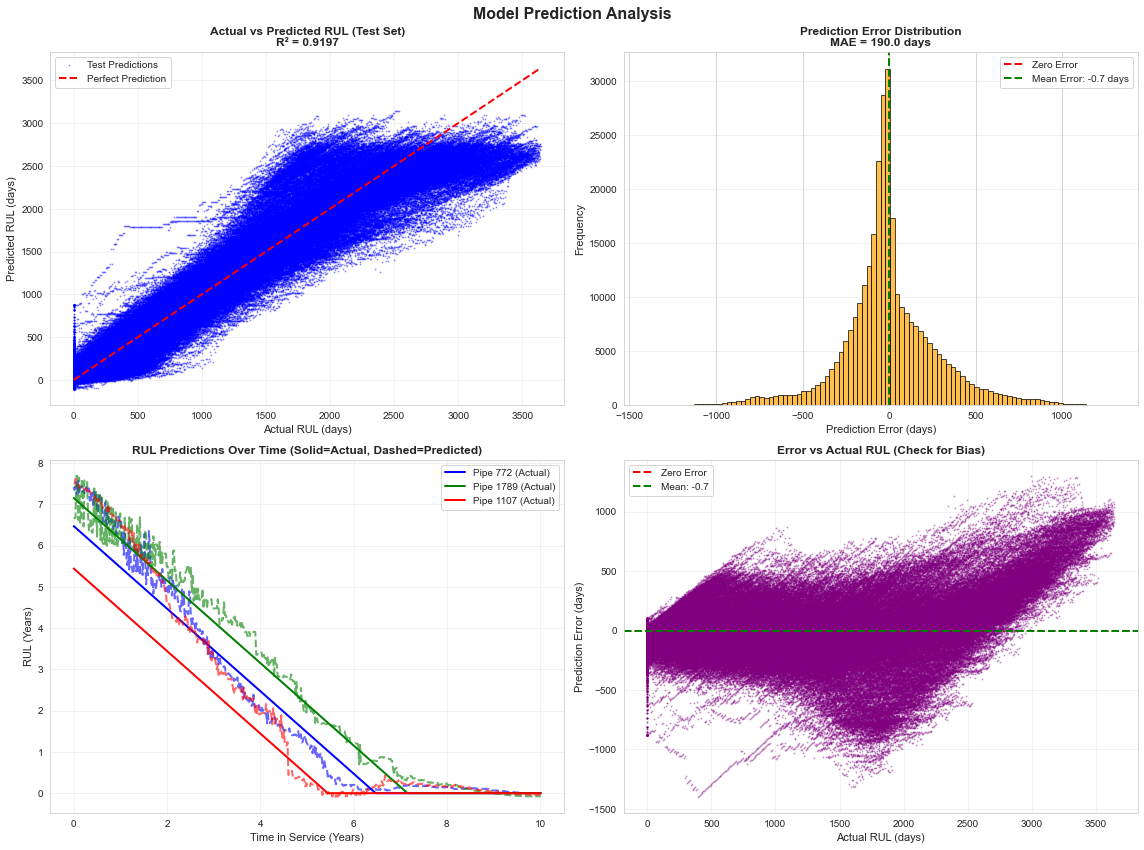

In [20]:
# Visualize predictions vs actual values
print("Creating prediction visualizations...")

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Prediction Analysis', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted (Testing Set)
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred, alpha=0.3, s=1, color='blue', label='Test Predictions')
ax.plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual RUL (days)', fontsize=11)
ax.set_ylabel('Predicted RUL (days)', fontsize=11)
ax.set_title(f'Actual vs Predicted RUL (Test Set)\nR² = {test_r2:.4f}', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Prediction Error Distribution
ax = axes[0, 1]
errors = y_test - y_test_pred
ax.hist(errors, bins=100, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.axvline(errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean Error: {errors.mean():.1f} days')
ax.set_xlabel('Prediction Error (days)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Prediction Error Distribution\nMAE = {test_mae:.1f} days', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: RUL Predictions Over Time (3 Sample Pipes)
ax = axes[1, 0]
np.random.seed(42)
sample_test_pipes = np.random.choice(test_pipes, size=3, replace=False)
colors_sample = ['blue', 'green', 'red']

for i, pipe_id in enumerate(sample_test_pipes):
    pipe_mask = df_timeseries['PIPE_ID'] == pipe_id
    pipe_data = df_timeseries[pipe_mask].copy()
    
    # Get predictions for this pipe
    pipe_X = X[pipe_mask]
    pipe_y_actual = y[pipe_mask]
    pipe_y_pred = model.predict(pipe_X)
    
    ax.plot(pipe_data['DAY'] / 365, pipe_y_actual / 365, 
            color=colors_sample[i], linewidth=2, label=f'Pipe {int(pipe_id)} (Actual)', linestyle='-')
    ax.plot(pipe_data['DAY'] / 365, pipe_y_pred / 365, 
            color=colors_sample[i], linewidth=2, alpha=0.6, linestyle='--')

ax.set_xlabel('Time in Service (Years)', fontsize=11)
ax.set_ylabel('RUL (Years)', fontsize=11)
ax.set_title('RUL Predictions Over Time (Solid=Actual, Dashed=Predicted)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Error vs RUL (Check for bias)
ax = axes[1, 1]
ax.scatter(y_test, errors, alpha=0.3, s=1, color='purple')
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.axhline(errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {errors.mean():.1f}')
ax.set_xlabel('Actual RUL (days)', fontsize=11)
ax.set_ylabel('Prediction Error (days)', fontsize=11)
ax.set_title('Error vs Actual RUL (Check for Bias)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Step 13b: Observations from visualisation of model prediction analysis

- Top-left: Points cluster around red line = good predictions
- Top-right: Errors centered near 0 = unbiased model
- Bottom-left: Dashed lines track solid lines = model captures trends
- Bottom-right: Random scatter around 0 = no systematic bias

## Step 14: Feature Importance Analysis

Which sensor readings matter most for predicting RUL?


FEATURE IMPORTANCE RANKING:
DAY                       █████████████████████████████████████████  82.79%
VIBRATION FREQUENCY       ███   7.46%
PRESSURE                  ███   6.36%
PIPE-LENGTH               █   2.18%
VELOCITY                     1.21%


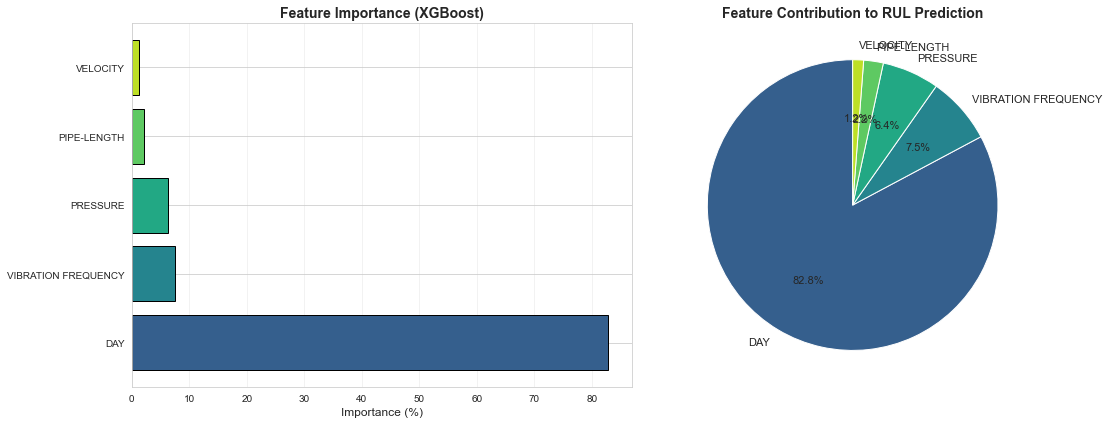

In [25]:
# Extract and visualize feature importance

# Get feature importance scores from XGBoost
feature_importance = model.feature_importances_
feature_names = X.columns

# Create DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance,
    'Importance (%)': feature_importance / feature_importance.sum() * 100
}).sort_values('Importance', ascending=False)

print("\nFEATURE IMPORTANCE RANKING:")

for idx, row in importance_df.iterrows():
    bar_length = int(row['Importance (%)'] / 2)  # Scale for display
    bar = '█' * bar_length
    print(f"{row['Feature']:<25} {bar} {row['Importance (%)']:>6.2f}%")


# Visualize feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors_bar = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
ax1.barh(importance_df['Feature'], importance_df['Importance (%)'], color=colors_bar, edgecolor='black')
ax1.set_xlabel('Importance (%)', fontsize=12)
ax1.set_title('Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Pie chart
ax2.pie(importance_df['Importance (%)'], labels=importance_df['Feature'], autopct='%1.1f%%',
        startangle=90, colors=colors_bar, textprops={'fontsize': 11})
ax2.set_title('Feature Contribution to RUL Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



## Step 14b: Interpret feature analysis results

In [22]:
# Interpret results
print("\nINTERPRETATION:")

top_feature = importance_df.iloc[0]
print(f"Most Important: {top_feature['Feature']} ({top_feature['Importance (%)']:.1f}%)")
print(f"   → This feature has the strongest influence on RUL predictions")

second_feature = importance_df.iloc[1]
print(f"\nSecond Most Important: {second_feature['Feature']} ({second_feature['Importance (%)']:.1f}%)")
print(f"   → Critical secondary indicator for failure prediction")

print(f"\nTop 3 features account for {importance_df.head(3)['Importance (%)'].sum():.1f}% of prediction power")


# Physical interpretation
print("\nPHYSICAL INTERPRETATION:")

for idx, row in importance_df.iterrows():
    feature_name = row['Feature']
    importance_pct = row['Importance (%)']
    
    interpretations = {
        'DAY': f"Time in service - Degradation accumulates over time ({importance_pct:.1f}% contribution)",
        'VIBRATION FREQUENCY': f"Structural integrity indicator : Increases as cracks form ({importance_pct:.1f}% contribution)",
        'PRESSURE': f"Strength indicator : Drops as structural weakening occurs ({importance_pct:.1f}% contribution)",
        'VELOCITY': f"Flow efficiency : Decreases as internal roughness grows ({importance_pct:.1f}% contribution)",
        'PIPE-LENGTH': f"Physical property : Longer pipes accumulate more stress ({importance_pct:.1f}% contribution)"
    }
    
    print(f"• {interpretations.get(feature_name, feature_name)}")




INTERPRETATION:
Most Important: DAY (82.8%)
   → This feature has the strongest influence on RUL predictions

Second Most Important: VIBRATION FREQUENCY (7.5%)
   → Critical secondary indicator for failure prediction

Top 3 features account for 96.6% of prediction power

PHYSICAL INTERPRETATION:
• Time in service - Degradation accumulates over time (82.8% contribution)
• Structural integrity indicator : Increases as cracks form (7.5% contribution)
• Strength indicator : Drops as structural weakening occurs (6.4% contribution)
• Physical property : Longer pipes accumulate more stress (2.2% contribution)
• Flow efficiency : Decreases as internal roughness grows (1.2% contribution)


## Step 14: Hyperparameter Tuning

improve the model by testing different hyperparameters

Testing 5 different model configurations
[1/5] Testing: Baseline (Current)
    Test MAE: 189.97 days | Test R²: 0.9197 | 

[2/5] Testing: More Trees
    Test MAE: 181.43 days | Test R²: 0.9246 | 

[3/5] Testing: Deeper Trees
    Test MAE: 178.13 days | Test R²: 0.9258 | 

[4/5] Testing: Lower Learning Rate
    Test MAE: 195.52 days | Test R²: 0.9163 | 

[5/5] Testing: Aggressive (Best Try)
    Test MAE: 176.88 days | Test R²: 0.9266 | 


HYPERPARAMETER TUNING RESULTS
        Configuration  n_estimators  max_depth  learning_rate  Train MAE   Test MAE  Train R²  Test R²  Overfitting Gap
   Baseline (Current)           100          6           0.10 171.577292 189.965717  0.935618 0.919710         0.015908
           More Trees           200          6           0.10 153.448830 181.430722  0.947253 0.924642         0.022611
         Deeper Trees           100          8           0.10 145.061463 178.125487  0.951382 0.925777         0.025604
  Lower Learning Rate           150          6  

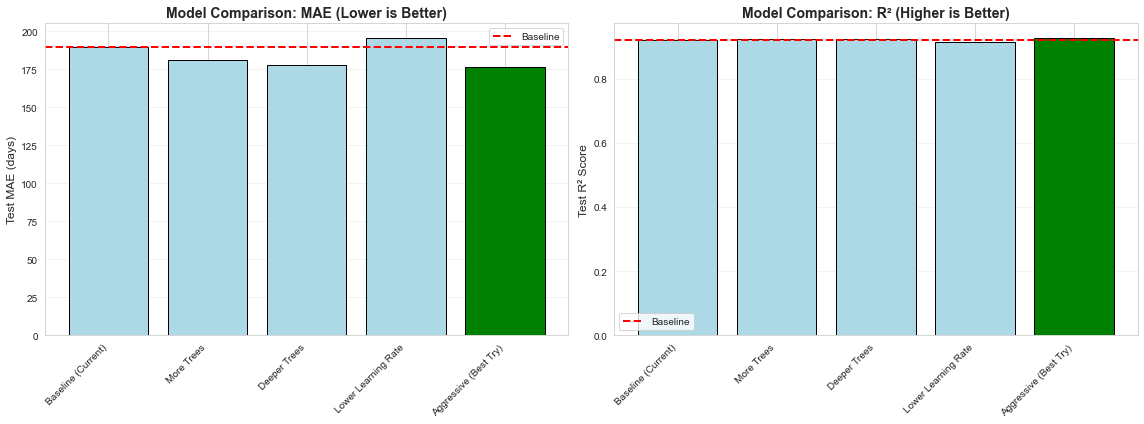


Hyperparameter tuning complete


In [26]:
# Hyperparameter tuning - test different configurations

print("Testing 5 different model configurations")

# Define hyperparameter configurations to test
configs = [
    {
        'name': 'Baseline (Current)',
        'params': {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8}
    },
    {
        'name': 'More Trees',
        'params': {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8}
    },
    {
        'name': 'Deeper Trees',
        'params': {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8}
    },
    {
        'name': 'Lower Learning Rate',
        'params': {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8}
    },
    {
        'name': 'Aggressive (Best Try)',
        'params': {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.85}
    }
]

# Store results
results = []

# Test each configuration
for i, config in enumerate(configs, 1):
    print(f"[{i}/5] Testing: {config['name']}")
    
    start_time = time.time()
    
    # Create and train model
    test_model = XGBRegressor(
        n_estimators=config['params']['n_estimators'],
        max_depth=config['params']['max_depth'],
        learning_rate=config['params']['learning_rate'],
        subsample=config['params']['subsample'],
        random_state=42,
        n_jobs=-1
    )
    
    test_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = test_model.predict(X_train)
    y_pred_test = test_model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    elapsed = time.time() - start_time
    
    # Store results
    results.append({
        'Configuration': config['name'],
        'n_estimators': config['params']['n_estimators'],
        'max_depth': config['params']['max_depth'],
        'learning_rate': config['params']['learning_rate'],
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Overfitting Gap': train_r2 - test_r2,
       
    })
    
    print(f"    Test MAE: {test_mae:.2f} days | Test R²: {test_r2:.4f} | \n")

# Create results DataFrame
results_df = pd.DataFrame(results)


print(f"\nHYPERPARAMETER TUNING RESULTS")

print(results_df.to_string(index=False))


# Find best configuration
best_idx = results_df['Test MAE'].idxmin()
best_config = results_df.iloc[best_idx]

print(f"\nBEST CONFIGURATION:")

print(f"Configuration: {best_config['Configuration']}")
print(f"  • n_estimators: {int(best_config['n_estimators'])}")
print(f"  • max_depth: {int(best_config['max_depth'])}")
print(f"  • learning_rate: {best_config['learning_rate']}")
print(f"\nPerformance:")
print(f"  • Test MAE: {best_config['Test MAE']:.2f} days")
print(f"  • Test R²: {best_config['Test R²']:.4f} ({best_config['Test R²']*100:.2f}%)")
print(f"  • Overfitting Gap: {best_config['Overfitting Gap']:.4f}")


# Compare to baseline
baseline = results_df[results_df['Configuration'] == 'Baseline (Current)'].iloc[0]
improvement_mae = baseline['Test MAE'] - best_config['Test MAE']
improvement_r2 = best_config['Test R²'] - baseline['Test R²']

print(f"\nIMPROVEMENT OVER BASELINE:")

if best_config['Configuration'] == 'Baseline (Current)':
    print("Baseline is already optimal and No improvement needed.")
else:
    print(f"  • MAE improved by: {improvement_mae:.2f} days ({improvement_mae/baseline['Test MAE']*100:.1f}%)")
    print(f"  • R² improved by: {improvement_r2:.4f} ({improvement_r2*100:.2f} percentage points)")
    
    if improvement_mae > 5:
        print(f"\nSignificant improvement, thus consider using {best_config['Configuration']} configuration.")
    elif improvement_mae > 0:
        print(f"\nSlight improvement. Baseline is already good, but '{best_config['Configuration']}' is marginally better.")
    else:
        print(f"\nNo improvement. Baseline configuration is optimal for this dataset.")


# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MAE Comparison
x_pos = np.arange(len(results_df))
colors = ['green' if i == best_idx else 'lightblue' for i in range(len(results_df))]

ax1.bar(x_pos, results_df['Test MAE'], color=colors, edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Configuration'], rotation=45, ha='right')
ax1.set_ylabel('Test MAE (days)', fontsize=12)
ax1.set_title('Model Comparison: MAE (Lower is Better)', fontsize=14, fontweight='bold')
ax1.axhline(baseline['Test MAE'], color='red', linestyle='--', linewidth=2, label='Baseline')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# R² Comparison
ax2.bar(x_pos, results_df['Test R²'], color=colors, edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['Configuration'], rotation=45, ha='right')
ax2.set_ylabel('Test R² Score', fontsize=12)
ax2.set_title('Model Comparison: R² (Higher is Better)', fontsize=14, fontweight='bold')
ax2.axhline(baseline['Test R²'], color='red', linestyle='--', linewidth=2, label='Baseline')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nHyperparameter tuning complete")

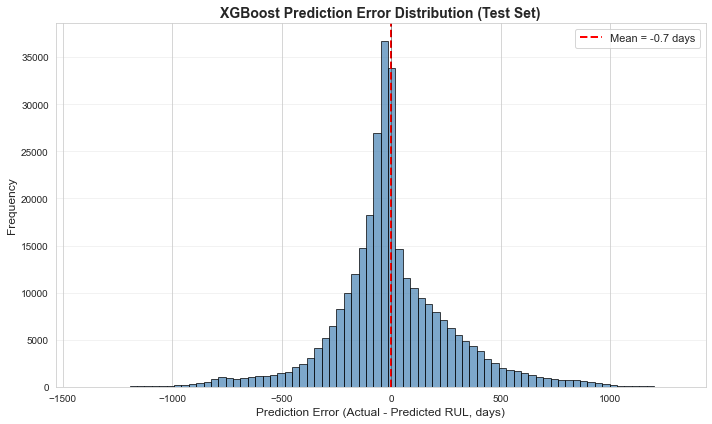

Error Distribution Statistics:
   Mean error: -0.7 days
   Std deviation: 275.5 days (RMSE)
   68% within: ±275 days
   95% within: ±551 days


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Generate error distribution histogram
errors = y_test - y_test_pred

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(errors, bins=80, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean = {errors.mean():.1f} days')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Prediction Error (Actual - Predicted RUL, days)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('XGBoost Prediction Error Distribution (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Error Distribution Statistics:")
print(f"   Mean error: {errors.mean():.1f} days")
print(f"   Std deviation: {errors.std():.1f} days (RMSE)")
print(f"   68% within: ±{errors.std():.0f} days")
print(f"   95% within: ±{2*errors.std():.0f} days")